# Experiment med PCA transformation för Occupation Space-representation

Undersök korrelationer för O*NET baserad Occupation Space (OCS) modell med yrken positionerade i en 2D PCA-transform.

1. OCS baserat på skills (befintligt)
2. OCS baserat på utbildningsdata
3. OCS baserat på abilities (förmågor)
4. OCS baserat på kunnande (knowledge)
5. Kombinationer av 1-4 (t.ex. PCA på sammanslagen matris)
6. Jämförelse och analys


In [20]:
import pandas as pd
import os

# Sätt sökvägar
data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
rel = pd.read_csv('db_29_3_text/Related Occupations.txt', sep='\t', encoding='utf-8')


# 1. OCS baserat på skills

In [ ]:
# Välj ut importance och level för alla yrken och skills
imp = skills[skills['Scale ID'] == 'IM'][['O*NET-SOC Code', 'Element ID', 'Data Value']]
lvl = skills[skills['Scale ID'] == 'LV'][['O*NET-SOC Code', 'Element ID', 'Data Value']]

# Koppla ihop importance och level för varje skill & yrke
merged = pd.merge(
    imp, lvl,
    on=['O*NET-SOC Code', 'Element ID'],
    suffixes=('_IM', '_LV')
)
merged['Weighted'] = merged['Data Value_IM'].astype(float) * merged['Data Value_LV'].astype(float)

# Bygg om till matris: rader = yrken, kolumner = skills, värde = weighted
skill_matrix = merged.pivot(
    index='O*NET-SOC Code',
    columns='Element ID',
    values='Weighted'
).fillna(0)


In [ ]:
import numpy as np
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

n_clusters = 50  # eller det antal du vill testa

# PCA till 2D
pca = PCA(n_components=2)
skill_coords = pca.fit_transform(skill_matrix.values)

# KMeans-klustring
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels = kmeans.fit_predict(skill_coords)

# Entropiberäkning (H)
def scaled_entropy(row):
    values = row.values + 1e-9
    probs = values / values.sum()
    return entropy(probs, base=2)

H = skill_matrix.apply(scaled_entropy, axis=1)

In [23]:
xi = np.arctan2(skill_coords[:, 1], skill_coords[:, 0]) % (2 * np.pi)
chi = np.linalg.norm(skill_coords, axis=1)
chi_scaled = chi / chi.max()
H_scaled = H / chi.max()

occ_titles = occ.set_index('O*NET-SOC Code').reindex(skill_matrix.index)['Title']

final_df = pd.DataFrame({
    'onet_code': skill_matrix.index,
    'title': occ_titles.values,
    'pc1': skill_coords[:, 0],
    'pc2': skill_coords[:, 1],
    'cluster': labels,
    'chi': chi_scaled,
    'xi': xi,
    'h': H_scaled.values
})

out_dir = "out"
os.makedirs(out_dir, exist_ok=True)
final_df.to_csv(os.path.join(out_dir, "onet_occupation_space.csv"), index=False)

final_df

,onet_code,title,pc1,pc2,cluster,chi,xi,h
0,11-1011.00,Chief Executives,40.495109,5.530049,30,1.000000,0.135721,0.114735
1,11-1011.03,Chief Sustainability Officers,22.652316,-0.648912,40,0.554467,6.254547,0.115787
2,11-1021.00,General and Operations Managers,15.897370,-2.219651,12,0.392738,6.144458,0.115860
3,11-2011.00,Advertising and Promotions Managers,17.454689,-5.945331,5,0.451163,5.954896,0.113747
4,11-2021.00,Marketing Managers,20.802204,-3.255744,34,0.515169,6.127935,0.114850
...,...,...,...,...,...,...,...,...
874,53-7071.00,Gas Compressor and Gas Pumping Station Operators,-17.436967,11.046866,13,0.505046,2.576882,0.118845
875,53-7072.00,"Pump Operators, Except Wellhead Pumpers",-14.920316,8.965923,36,0.425901,2.600497,0.120798
876,53-7073.00,Wellhead Pumpers,-24.433747,9.388444,48,0.640440,2.774745,0.115188
877,53-7081.00,Refuse and Recyclable Material Collectors,-26.702458,-5.499227,9,0.667047,3.344698,0.112676


Primary-Short inom topp 5: 0.057114477278371
Primary-Long inom topp 5: 0.04072398190045249
Supplemental inom topp 5: 0.023270055113288425
Histogramdata sparad i out/occs_histogram.csv


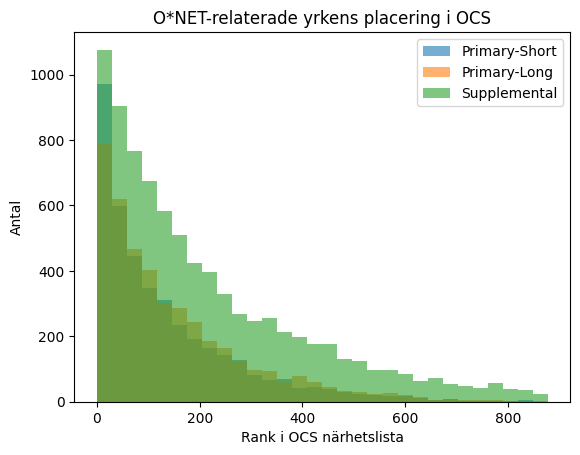

In [24]:
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Bygg en avståndsmatris (exempel med (pc1, pc2))
coords = final_df[['pc1', 'pc2']].values
codes = final_df['onet_code'].values
dist_matrix = cdist(coords, coords)  # [i, j] = avstånd mellan yrke i och yrke j

# 2. För varje yrke: skapa lista på andra yrken sorterad efter avstånd
nearest_ranks = {}
for i, code in enumerate(codes):
    dists = dist_matrix[i]
    sorted_indices = np.argsort(dists)
    sorted_codes = codes[sorted_indices]
    nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}

# 3. För varje rad i rel: kolla vilken rank relaterad yrkeskod har för start-yrket
rel['occs_rank'] = rel.apply(
    lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
    axis=1
)

# 4. Statistik: Hur många O*NET-relaterade yrken ligger bland de 1, 3, 5, 10 närmaste i OCS?
primary_short_ranks = rel.loc[rel['Relatedness Tier'] == 'Primary-Short', 'occs_rank'].dropna()
primary_long_ranks  = rel.loc[rel['Relatedness Tier'] == 'Primary-Long', 'occs_rank'].dropna()
supplemental_ranks  = rel.loc[rel['Relatedness Tier'] == 'Supplemental', 'occs_rank'].dropna()

print('Primary-Short inom topp 5:', (primary_short_ranks <= 5).mean())
print('Primary-Long inom topp 5:', (primary_long_ranks <= 5).mean())
print('Supplemental inom topp 5:', (supplemental_ranks <= 5).mean())

# 5. Skapa gemensamma bins (t.ex. 30 bins, från min till max rank)
max_rank = int(max(primary_short_ranks.max(), primary_long_ranks.max(), supplemental_ranks.max()))
bins = np.linspace(0, max_rank + 1, 31)  # 30 bins

counts_short = np.histogram(primary_short_ranks, bins=bins)[0]
counts_long = np.histogram(primary_long_ranks, bins=bins)[0]
counts_supp = np.histogram(supplemental_ranks, bins=bins)[0]

hist_df = pd.DataFrame({
    'bin_left': bins[:-1],
    'bin_right': bins[1:],
    'count_primary_short': counts_short,
    'count_primary_long': counts_long,
    'count_supplemental': counts_supp
})

# 6. Spara till fil
import os
os.makedirs('out', exist_ok=True)
hist_df.to_csv('out/occs_histogram.csv', index=False)
print("Histogramdata sparad i out/occs_histogram.csv")

# 7. Visualisera
plt.hist(primary_short_ranks, bins=bins, alpha=0.6, label='Primary-Short')
plt.hist(primary_long_ranks, bins=bins, alpha=0.6, label='Primary-Long')
plt.hist(supplemental_ranks, bins=bins, alpha=0.6, label='Supplemental')
plt.xlabel('Rank i OCS närhetslista')
plt.ylabel('Antal')
plt.legend()
plt.title('O*NET-relaterade yrkens placering i OCS')
plt.show()


# 2. OCS baserat på utbildning

In [25]:
import pandas as pd
from sklearn.decomposition import PCA

# Läs in utbildningsdata
edu = pd.read_csv('db_29_3_text/Education, Training, and Experience.txt', sep='\t', encoding='utf-8')

# Filtrera ut utbildningsnivå-data (element_id == '2.D.1')
edu_lvl = edu[edu['Element ID'] == '2.D.1']

# Pivotera till matris: index=O*NET-SOC Code, columns=utbildningsnivå (Category), values=Data Value
edu_matrix = edu_lvl.pivot_table(index='O*NET-SOC Code', columns='Category', values='Data Value', fill_value=0)

# PCA (t.ex. 2 komponenter)
pca = PCA(n_components=2)
edu_coords = pca.fit_transform(edu_matrix.values)

# Lägg till i DataFrame
edu_df = pd.DataFrame({
    'onet_code': edu_matrix.index,
    'edu_pc1': edu_coords[:, 0],
    'edu_pc2': edu_coords[:, 1],
})

# Nu kan du fortsätta på samma sätt som du gjorde för skills-OCS!
edu_df

,onet_code,edu_pc1,edu_pc2
0,11-1011.00,-35.654584,-11.076295
1,11-1011.03,-36.620262,-26.612326
2,11-1021.00,-0.139839,12.060556
3,11-2011.00,-36.689648,24.533040
4,11-2021.00,-44.292758,13.299937
...,...,...,...
853,53-7071.00,39.907111,6.207175
854,53-7072.00,26.923572,15.533867
855,53-7073.00,51.646754,10.265322
856,53-7081.00,51.694461,10.839542


Primary-Short inom topp 5: 0.03042223970626803
Primary-Long inom topp 5: 0.02505637684790779
Supplemental inom topp 5: 0.01718790385112432
Histogramdata sparad i out/occs_histogram_edu.csv


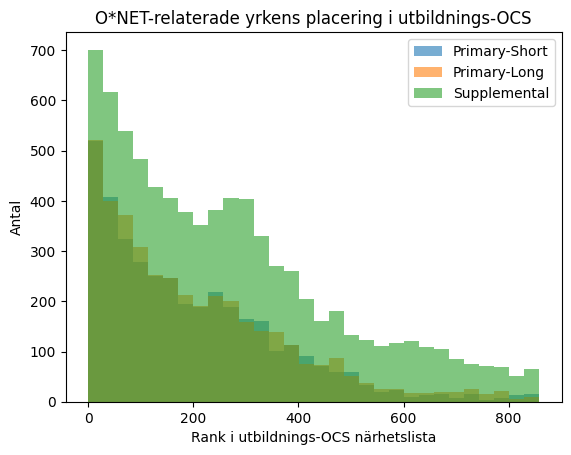

In [26]:
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Bygg en avståndsmatris utifrån utbildnings-PCA
coords = edu_df[['edu_pc1', 'edu_pc2']].values
codes = edu_df['onet_code'].values
dist_matrix = cdist(coords, coords)

# 2. Skapa lista över andra yrken sorterad efter avstånd
nearest_ranks = {}
for i, code in enumerate(codes):
    dists = dist_matrix[i]
    sorted_indices = np.argsort(dists)
    sorted_codes = codes[sorted_indices]
    nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}

# 3. För varje rad i rel: kolla rank för relaterad yrkeskod
rel['edu_rank'] = rel.apply(
    lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
    axis=1
)

# 4. Statistik: Hur många O*NET-relaterade yrken ligger bland de 1, 3, 5, 10 närmaste i utbildnings-OCS?
primary_short_ranks = rel.loc[rel['Relatedness Tier'] == 'Primary-Short', 'edu_rank'].dropna()
primary_long_ranks  = rel.loc[rel['Relatedness Tier'] == 'Primary-Long', 'edu_rank'].dropna()
supplemental_ranks  = rel.loc[rel['Relatedness Tier'] == 'Supplemental', 'edu_rank'].dropna()

print('Primary-Short inom topp 5:', (primary_short_ranks <= 5).mean())
print('Primary-Long inom topp 5:', (primary_long_ranks <= 5).mean())
print('Supplemental inom topp 5:', (supplemental_ranks <= 5).mean())

# 5. Gemensamma bins
max_rank = int(max(primary_short_ranks.max(), primary_long_ranks.max(), supplemental_ranks.max()))
bins = np.linspace(0, max_rank + 1, 31)  # 30 bins

counts_short = np.histogram(primary_short_ranks, bins=bins)[0]
counts_long = np.histogram(primary_long_ranks, bins=bins)[0]
counts_supp = np.histogram(supplemental_ranks, bins=bins)[0]

hist_df = pd.DataFrame({
    'bin_left': bins[:-1],
    'bin_right': bins[1:],
    'count_primary_short': counts_short,
    'count_primary_long': counts_long,
    'count_supplemental': counts_supp
})

# 6. Spara till fil
os.makedirs('out', exist_ok=True)
hist_df.to_csv('out/occs_histogram_edu.csv', index=False)
print("Histogramdata sparad i out/occs_histogram_edu.csv")

# 7. Visualisera
plt.hist(primary_short_ranks, bins=bins, alpha=0.6, label='Primary-Short')
plt.hist(primary_long_ranks, bins=bins, alpha=0.6, label='Primary-Long')
plt.hist(supplemental_ranks, bins=bins, alpha=0.6, label='Supplemental')
plt.xlabel('Rank i utbildnings-OCS närhetslista')
plt.ylabel('Antal')
plt.legend()
plt.title('O*NET-relaterade yrkens placering i utbildnings-OCS')
plt.show()


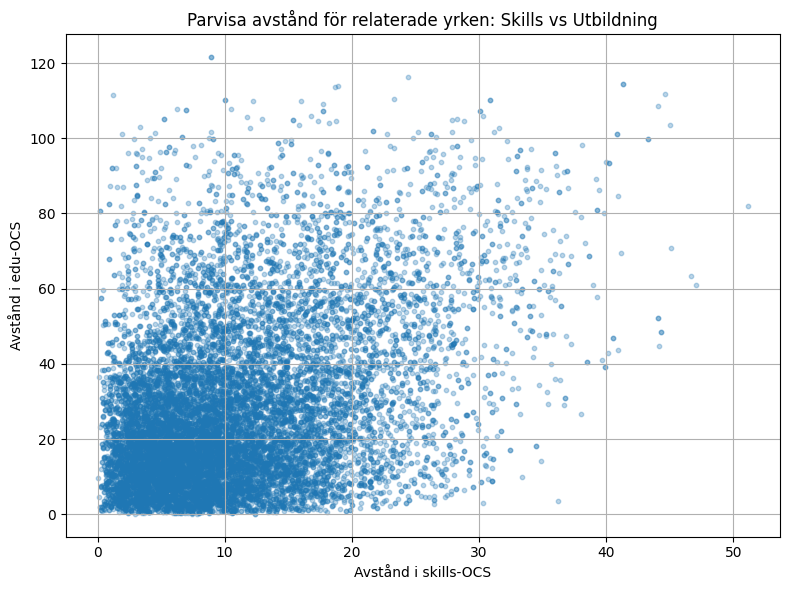

In [27]:
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrahera koder och koordinater (ordna så de matchar)
# Säkerställ att edu_df har samma ordning som final_df (annars kan index-mapping gå fel)
edu_df_matched = edu_df.set_index('onet_code').reindex(final_df['onet_code']).reset_index()
coords_skills = final_df[['pc1', 'pc2']].values
coords_edu = edu_df_matched[['edu_pc1', 'edu_pc2']].values
codes = final_df['onet_code'].values

# 2. Bygg avståndsmatriser
dist_matrix_skills = cdist(coords_skills, coords_skills)
dist_matrix_edu = cdist(coords_edu, coords_edu)

# 3. Bygg lookup: kod -> index
code2idx = {code: idx for idx, code in enumerate(codes)}

# 4. Skapa scatter-data för varje rad i rel (bara för par som finns i båda dataseten)
x = []
y = []
mask = rel['O*NET-SOC Code'].isin(code2idx) & rel['Related O*NET-SOC Code'].isin(code2idx)
for _, row in rel[mask].iterrows():
    i = code2idx[row['O*NET-SOC Code']]
    j = code2idx[row['Related O*NET-SOC Code']]
    x.append(dist_matrix_skills[i, j])
    y.append(dist_matrix_edu[i, j])

# 5. Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.3, s=10)
plt.xlabel('Avstånd i skills-OCS')
plt.ylabel('Avstånd i edu-OCS')
plt.title('Parvisa avstånd för relaterade yrken: Skills vs Utbildning')
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
import scipy.stats as stats
import numpy as np

# Om du redan har listorna x och y från tidigare cell
x = np.array(x)
y = np.array(y)
mask_valid = ~np.isnan(x) & ~np.isnan(y)
x = x[mask_valid]
y = y[mask_valid]


print("Antal par:", len(x))

pearson_corr, pearson_p = stats.pearsonr(x, y)
spearman_corr, spearman_p = stats.spearmanr(x, y)
kendall_corr, kendall_p = stats.kendalltau(x, y)

print(f"Pearson correlation: {pearson_corr:.3f} (p={pearson_p:.3g})")
print(f"Spearman correlation: {spearman_corr:.3f} (p={spearman_p:.3g})")
print(f"Kendall correlation: {kendall_corr:.3f} (p={kendall_p:.3g})")


Antal par: 15542
Pearson correlation: 0.375 (p=0)
Spearman correlation: 0.303 (p=0)
Kendall correlation: 0.204 (p=0)


# Abilities

Primary-Short inom topp 5: 0.040725105537621056
Primary-Long inom topp 5: 0.032864967849487975
Supplemental inom topp 5: 0.025229638701775872
Histogramdata sparad i out/occs_histogram_abilities.csv


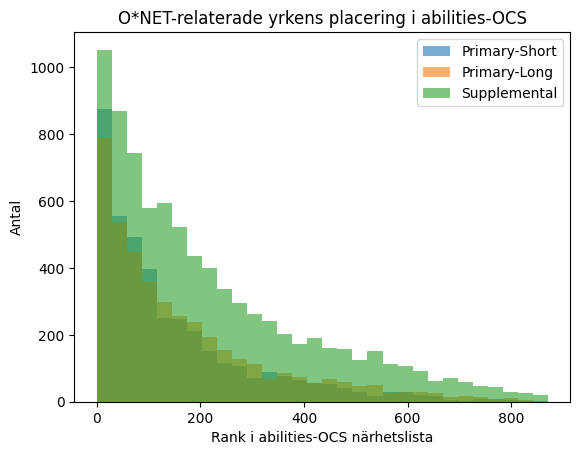

In [29]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os

# 1. Läs in Abilities
abilities = pd.read_csv('db_29_3_text/Abilities.txt', sep='\t', encoding='utf-8')

# 2. Skapa matris: index=O*NET-SOC Code, kolumner=Ability Element ID, värden=Data Value
pivot = abilities.pivot_table(index='O*NET-SOC Code', columns='Element ID', values='Data Value', fill_value=0)

# 3. PCA till 2 komponenter
pca = PCA(n_components=2)
abilities_coords = pca.fit_transform(pivot.values)

# 4. Lägg in i DataFrame
abilities_df = pd.DataFrame({
    'onet_code': pivot.index,
    'ab_pc1': abilities_coords[:, 0],
    'ab_pc2': abilities_coords[:, 1],
})

# --- Antag att du har din rel-tabell inläst som DataFrame 'rel' ---

# 5. Bygg en avståndsmatris på (ab_pc1, ab_pc2)
coords = abilities_df[['ab_pc1', 'ab_pc2']].values
codes = abilities_df['onet_code'].values
dist_matrix = cdist(coords, coords)

# 6. Skapa lista över andra yrken sorterad efter avstånd
nearest_ranks = {}
for i, code in enumerate(codes):
    dists = dist_matrix[i]
    sorted_indices = np.argsort(dists)
    sorted_codes = codes[sorted_indices]
    nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}

# 7. För varje rad i rel: kolla rank för relaterad yrkeskod
rel['abilities_rank'] = rel.apply(
    lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
    axis=1
)

# 8. Statistik: Hur många O*NET-relaterade yrken ligger bland de 1, 3, 5, 10 närmaste i Abilities-OCS?
primary_short_ranks = rel.loc[rel['Relatedness Tier'] == 'Primary-Short', 'abilities_rank'].dropna()
primary_long_ranks  = rel.loc[rel['Relatedness Tier'] == 'Primary-Long', 'abilities_rank'].dropna()
supplemental_ranks  = rel.loc[rel['Relatedness Tier'] == 'Supplemental', 'abilities_rank'].dropna()

print('Primary-Short inom topp 5:', (primary_short_ranks <= 5).mean())
print('Primary-Long inom topp 5:', (primary_long_ranks <= 5).mean())
print('Supplemental inom topp 5:', (supplemental_ranks <= 5).mean())

# 9. Gemensamma bins för histogram
max_rank = int(max(primary_short_ranks.max(), primary_long_ranks.max(), supplemental_ranks.max()))
bins = np.linspace(0, max_rank + 1, 31)  # 30 bins

counts_short = np.histogram(primary_short_ranks, bins=bins)[0]
counts_long = np.histogram(primary_long_ranks, bins=bins)[0]
counts_supp = np.histogram(supplemental_ranks, bins=bins)[0]

hist_df = pd.DataFrame({
    'bin_left': bins[:-1],
    'bin_right': bins[1:],
    'count_primary_short': counts_short,
    'count_primary_long': counts_long,
    'count_supplemental': counts_supp
})

# 10. Spara till fil
os.makedirs('out', exist_ok=True)
hist_df.to_csv('out/occs_histogram_abilities.csv', index=False)
print("Histogramdata sparad i out/occs_histogram_abilities.csv")

# 11. Visualisera
plt.hist(primary_short_ranks, bins=bins, alpha=0.6, label='Primary-Short')
plt.hist(primary_long_ranks, bins=bins, alpha=0.6, label='Primary-Long')
plt.hist(supplemental_ranks, bins=bins, alpha=0.6, label='Supplemental')
plt.xlabel('Rank i abilities-OCS närhetslista')
plt.ylabel('Antal')
plt.legend()
plt.title('O*NET-relaterade yrkens placering i abilities-OCS')
plt.show()
